# Retail Demand Forecasting using Walmart Store Sales Data

## Business Objective

The objective of this project is to develop a machine learning model that accurately forecasts weekly sales for Walmart stores. Accurate demand forecasting enables better inventory management, workforce planning, promotion strategies, and supply chain optimization while minimizing stock shortages and excess inventory.

## Problem Statement

Walmart operates hundreds of stores across different locations, each experiencing varying customer demand influenced by multiple internal and external factors. Predicting future weekly sales is a challenging task because sales fluctuate due to holidays, seasonal trends, store size, weather conditions, fuel prices, and economic indicators.

The objective of this project is to build an accurate machine learning model capable of forecasting weekly sales for different Walmart stores. The solution should compare multiple regression models, evaluate their performance using appropriate metrics, analyze residual errors, explain model predictions using SHAP and LIME, and provide meaningful business insights.

# DATA LOADING & PREPROCESSING

In [17]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date & Time
from datetime import datetime

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [18]:
train = pd.read_csv("data/train - Walmart Sales Forecast.csv")
test = pd.read_csv("data/test - Walmart Sales Forecast.csv")
stores = pd.read_csv("data/stores - Walmart Sales Forecast.csv")
features = pd.read_csv("data/features - Walmart Sales Forecast.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [19]:
datasets = {
    "Train": train,
    "Test": test,
    "Stores": stores,
    "Features": features
}

for name, df in datasets.items():
    print(f"{name} Dataset Shape : {df.shape}")

Train Dataset Shape : (421570, 5)
Test Dataset Shape : (115064, 4)
Stores Dataset Shape : (45, 3)
Features Dataset Shape : (8190, 12)


In [20]:
for name, df in datasets.items():
    print("="*80)
    print(name)
    display(df.head())

Train


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


Test


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


Stores


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


Features


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [21]:
for name, df in datasets.items():
    print("="*80)
    print(name)
    print("="*80)
    print(df.info())

Train
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB
None
Test
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Store      115064 non-null  int64 
 1   Dept       115064 non-null  int64 
 2   Date       115064 non-null  object
 3   IsHoliday  115064 non-null  bool  
dtypes: bool(1), int64(2), object(1)
memory usage: 2.7+ MB
None
Stores
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Dat

In [22]:
for name, df in datasets.items():
    
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    
    print("="*80)
    print(name)
    print("="*80)
    
    if len(missing) == 0:
        print("No Missing Values\n")
    else:
        display(missing.sort_values(ascending=False))

Train
No Missing Values

Test
No Missing Values

Stores
No Missing Values

Features


MarkDown2       5269
MarkDown4       4726
MarkDown3       4577
MarkDown1       4158
MarkDown5       4140
CPI              585
Unemployment     585
dtype: int64

In [23]:
for name, df in datasets.items():
    print(f"{name} Duplicate Rows : {df.duplicated().sum()}")

Train Duplicate Rows : 0
Test Duplicate Rows : 0
Stores Duplicate Rows : 0
Features Duplicate Rows : 0


In [24]:
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])
features["Date"] = pd.to_datetime(features["Date"])

print("Date Columns Converted Successfully")

Date Columns Converted Successfully


In [25]:
train_df = train.merge(
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

train_df = train_df.merge(
    stores,
    on="Store",
    how="left"
)

print("Merged Training Dataset Shape :", train_df.shape)

Merged Training Dataset Shape : (421570, 16)


In [26]:
test_df = test.merge(
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

test_df = test_df.merge(
    stores,
    on="Store",
    how="left"
)

print("Merged Testing Dataset Shape :", test_df.shape)

Merged Testing Dataset Shape : (115064, 15)


In [27]:
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [28]:
# Check missing values in merged training dataset

missing_values = train_df.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]

missing_values

MarkDown2    310322
MarkDown4    286603
MarkDown3    284479
MarkDown1    270889
MarkDown5    270138
dtype: int64

In [29]:
# Fill missing values in MarkDown columns with 0

markdown_columns = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

for col in markdown_columns:
    train_df[col] = train_df[col].fillna(0)
    test_df[col] = test_df[col].fillna(0)

print("MarkDown missing values handled successfully.")

MarkDown missing values handled successfully.


In [30]:
# Fill remaining numerical missing values using median

numerical_columns = train_df.select_dtypes(include=["float64", "int64"]).columns

for col in numerical_columns:

    if train_df[col].isnull().sum() > 0:

        median_value = train_df[col].median()

        train_df[col].fillna(median_value, inplace=True)

        if col in test_df.columns:
            test_df[col].fillna(median_value, inplace=True)

print("Remaining numerical missing values handled successfully.")

Remaining numerical missing values handled successfully.


In [31]:
# Verify missing values after preprocessing

train_df.isnull().sum().sort_values(ascending=False).head(15)

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
dtype: int64

In [32]:
def create_date_features(df):

    df["Year"] = df["Date"].dt.year

    df["Month"] = df["Date"].dt.month

    df["Quarter"] = df["Date"].dt.quarter

    df["Week"] = df["Date"].dt.isocalendar().week.astype(int)

    df["Day"] = df["Date"].dt.day

    df["DayOfWeek"] = df["Date"].dt.dayofweek

    df["DayOfYear"] = df["Date"].dt.dayofyear

    df["IsMonthStart"] = df["Date"].dt.is_month_start.astype(int)

    df["IsMonthEnd"] = df["Date"].dt.is_month_end.astype(int)

    return df

In [33]:
train_df = create_date_features(train_df)

test_df = create_date_features(test_df)

print("Date Features Created Successfully.")

Date Features Created Successfully.


In [34]:
date_columns = [
    "Date",
    "Year",
    "Quarter",
    "Month",
    "Week",
    "Day",
    "DayOfWeek",
    "DayOfYear",
    "IsMonthStart",
    "IsMonthEnd"
]

train_df[date_columns].head()

,Date,Year,Quarter,Month,Week,Day,DayOfWeek,DayOfYear,IsMonthStart,IsMonthEnd
0,2010-02-05,2010,1,2,5,5,4,36,0,0
1,2010-02-12,2010,1,2,6,12,4,43,0,0
2,2010-02-19,2010,1,2,7,19,4,50,0,0
3,2010-02-26,2010,1,2,8,26,4,57,0,0
4,2010-03-05,2010,1,3,9,5,4,64,0,0


In [35]:
train_df["Type"] = train_df["Type"].astype("category")
test_df["Type"] = test_df["Type"].astype("category")

train_df["IsHoliday"] = train_df["IsHoliday"].astype(int)
test_df["IsHoliday"] = test_df["IsHoliday"].astype(int)

print("Data Types Optimized.")

Data Types Optimized.


In [36]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  int64         
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     421570 non-null  float64       
 8   MarkDown2     421570 non-null  float64       
 9   MarkDown3     421570 non-null  float64       
 10  MarkDown4     421570 non-null  float64       
 11  MarkDown5     421570 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  category      
 15  Size          421

In [37]:
train_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Store,421570.0,22.200546,1.0,11.0,22.0,33.0,45.0,12.785297
Dept,421570.0,44.260317,1.0,18.0,37.0,74.0,99.0,30.492054
Date,421570,2011-06-18 08:30:31.963375104,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,421570.0,15981.258123,-4988.94,2079.65,7612.03,20205.8525,693099.36,22711.183519
IsHoliday,421570.0,0.070358,0.0,0.0,0.0,0.0,1.0,0.25575
Temperature,421570.0,60.090059,-2.06,46.68,62.09,74.28,100.14,18.447931
Fuel_Price,421570.0,3.361027,2.472,2.933,3.452,3.738,4.468,0.458515
MarkDown1,421570.0,2590.074819,0.0,0.0,0.0,2809.05,88646.76,6052.385934
MarkDown2,421570.0,879.974298,-265.76,0.0,0.0,2.2,104519.54,5084.538801
MarkDown3,421570.0,468.087665,-29.1,0.0,0.0,4.54,141630.61,5528.873453


In [38]:
import os

os.makedirs("outputs", exist_ok=True)

train_df.to_csv("outputs/cleaned_train.csv", index=False)

test_df.to_csv("outputs/cleaned_test.csv", index=False)

print("Cleaned datasets saved successfully.")

Cleaned datasets saved successfully.


In [39]:
print("Training Dataset Shape :", train_df.shape)

print("Testing Dataset Shape :", test_df.shape)

Training Dataset Shape : (421570, 25)
Testing Dataset Shape : (115064, 24)


# Exploratory Data Analysis (EDA)

In [40]:
# Figure Style

plt.style.use("ggplot")

sns.set(font_scale=1.1)

print("Visualization Settings Applied")

Visualization Settings Applied


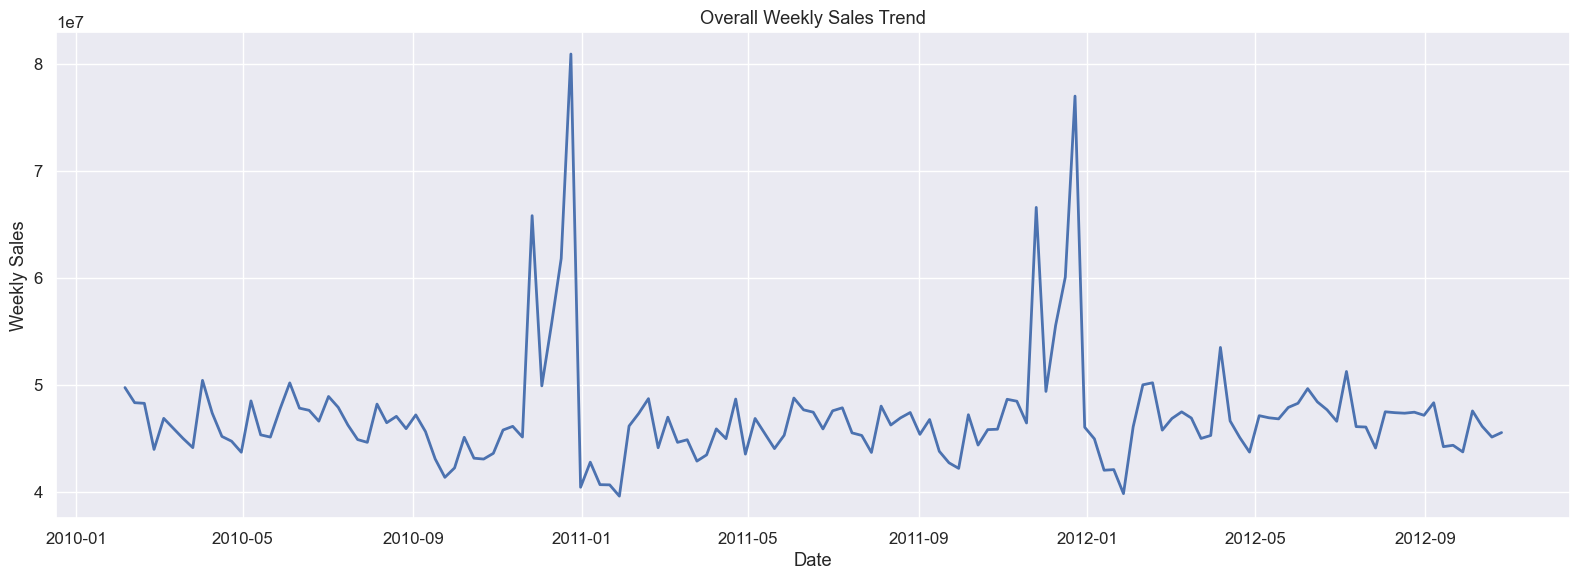

In [41]:
weekly_sales = (
    train_df
    .groupby("Date")["Weekly_Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(16,6))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Weekly_Sales"],
    linewidth=2
)

plt.title("Overall Weekly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.tight_layout()

plt.show()

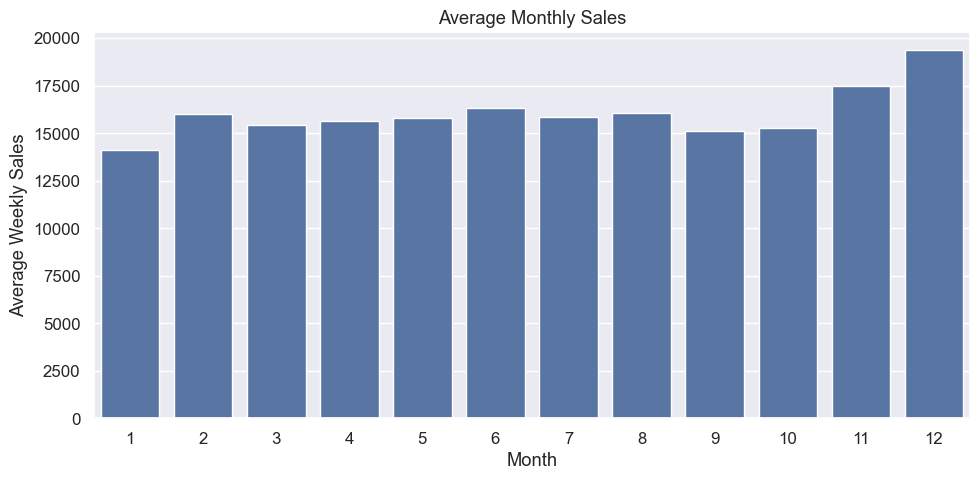

In [42]:
monthly_sales = (
    train_df
    .groupby("Month")["Weekly_Sales"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=monthly_sales,
    x="Month",
    y="Weekly_Sales"
)

plt.title("Average Monthly Sales")

plt.xlabel("Month")

plt.ylabel("Average Weekly Sales")

plt.tight_layout()

plt.show()

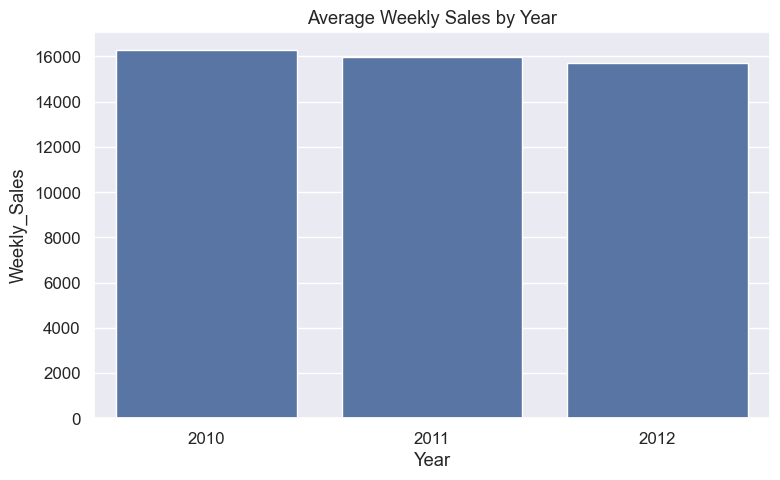

In [43]:
yearly_sales = (
    train_df
    .groupby("Year")["Weekly_Sales"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=yearly_sales,
    x="Year",
    y="Weekly_Sales"
)

plt.title("Average Weekly Sales by Year")

plt.tight_layout()

plt.show()

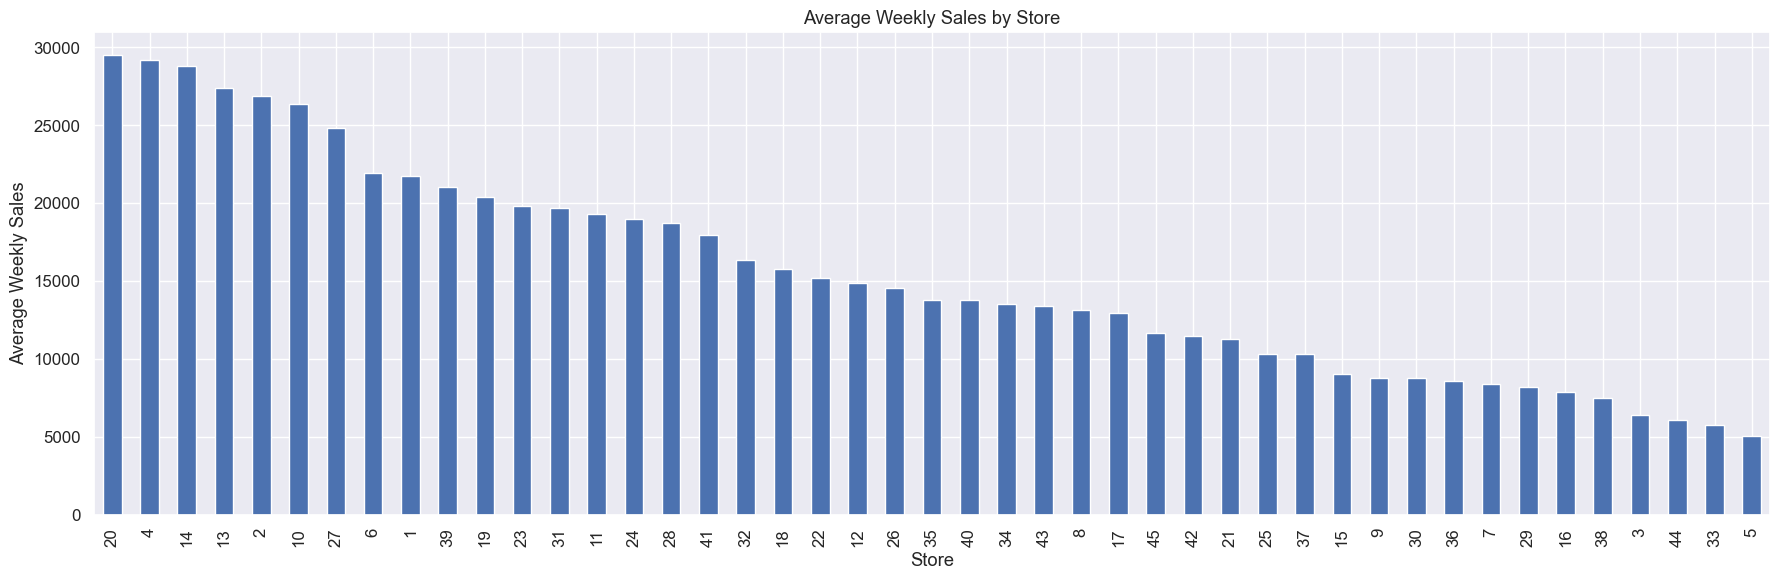

In [44]:
store_sales = (
    train_df
    .groupby("Store")["Weekly_Sales"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(18,6))

store_sales.plot(kind="bar")

plt.title("Average Weekly Sales by Store")

plt.xlabel("Store")

plt.ylabel("Average Weekly Sales")

plt.tight_layout()

plt.show()

In [45]:
top10 = (
    train_df
    .groupby("Store")["Weekly_Sales"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top10

Store
20    29508.301592
4     29161.210415
14    28784.851727
13    27355.136891
2     26898.070031
10    26332.303819
27    24826.984536
6     21913.243624
1     21710.543621
39    21000.763562
Name: Weekly_Sales, dtype: float64

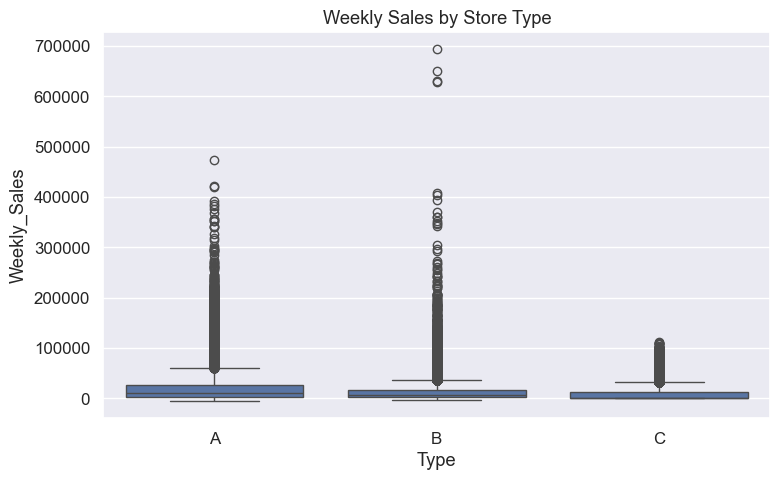

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=train_df,
    x="Type",
    y="Weekly_Sales"
)

plt.title("Weekly Sales by Store Type")

plt.tight_layout()

plt.show()

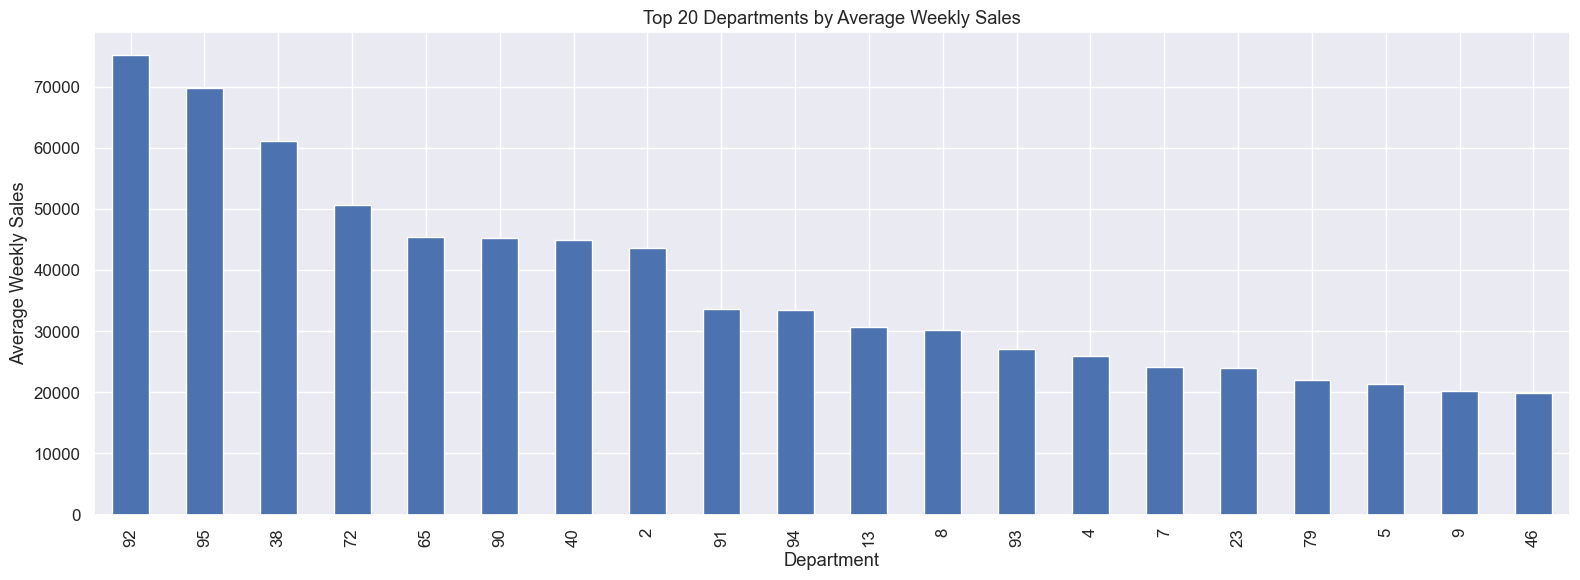

In [47]:
department_sales = (
    train_df
    .groupby("Dept")["Weekly_Sales"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(16,6))

department_sales.plot(kind="bar")

plt.title("Top 20 Departments by Average Weekly Sales")

plt.xlabel("Department")

plt.ylabel("Average Weekly Sales")

plt.tight_layout()

plt.show()

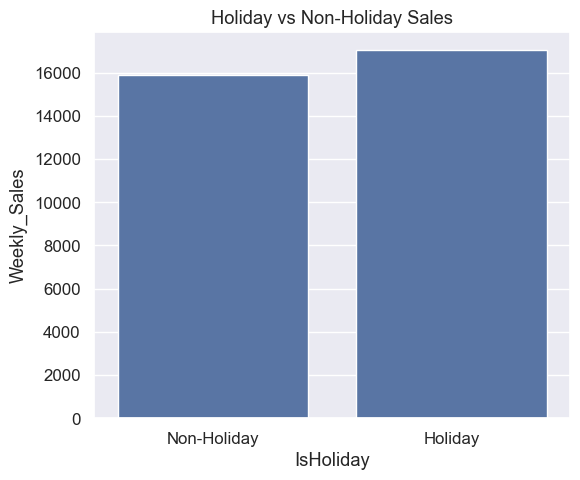

In [48]:
holiday_sales = (
    train_df
    .groupby("IsHoliday")["Weekly_Sales"]
    .mean()
    .reset_index()
)

holiday_sales["IsHoliday"] = holiday_sales["IsHoliday"].map({
    0:"Non-Holiday",
    1:"Holiday"
})

plt.figure(figsize=(6,5))

sns.barplot(
    data=holiday_sales,
    x="IsHoliday",
    y="Weekly_Sales"
)

plt.title("Holiday vs Non-Holiday Sales")

plt.tight_layout()

plt.show()

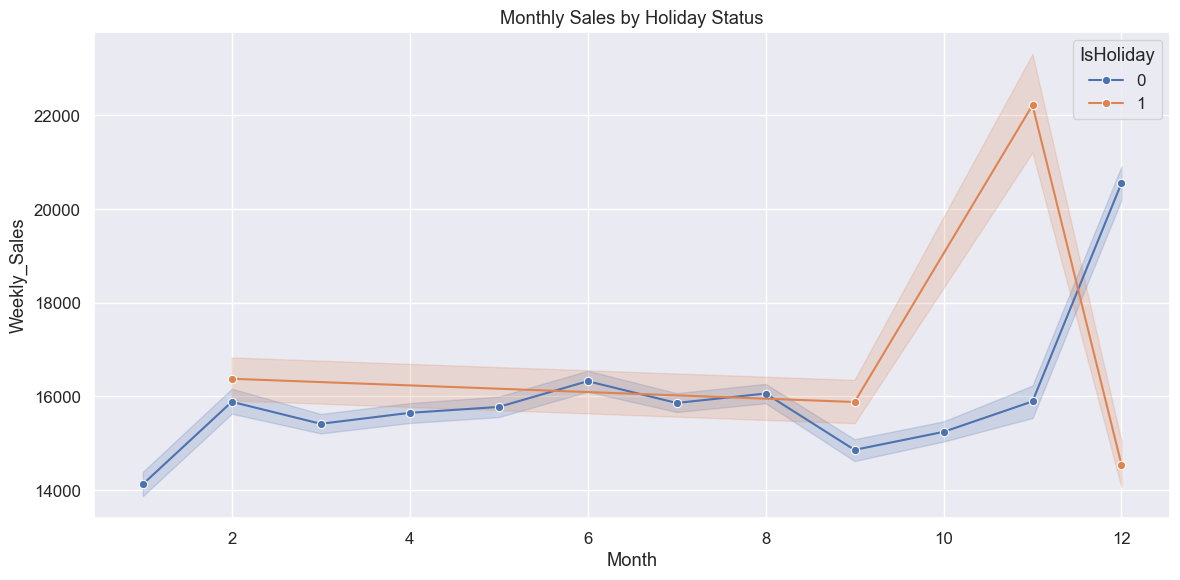

In [49]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=train_df,
    x="Month",
    y="Weekly_Sales",
    hue="IsHoliday",
    estimator="mean",
    marker="o"
)

plt.title("Monthly Sales by Holiday Status")

plt.tight_layout()

plt.show()

In [50]:
# Select numerical columns
numerical_columns = train_df.select_dtypes(include=["int64", "float64"]).columns

# Correlation matrix
correlation_matrix = train_df[numerical_columns].corr()

correlation_matrix.head()

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Week,IsMonthStart,IsMonthEnd
Store,1.000000,0.024004,-0.085195,-0.000548,-0.050097,0.065290,-0.059844,-0.033829,-0.020331,-0.042724,-0.012452,-0.211088,0.208552,-0.182881,0.001031,0.000627,-0.000223
Dept,0.024004,1.000000,0.148032,0.000916,0.004437,0.003572,0.001494,0.000587,0.001475,0.001937,0.002668,-0.007477,0.007837,-0.002966,0.000882,-0.000862,-0.000379
Weekly_Sales,-0.085195,0.148032,1.000000,0.012774,-0.002312,-0.000120,0.047172,0.020716,0.038562,0.037467,0.050465,-0.020921,-0.025864,0.243828,0.027673,-0.004047,-0.009319
IsHoliday,-0.000548,0.000916,0.012774,1.000000,-0.155949,-0.078281,-0.003521,0.207604,0.266471,0.011565,-0.015235,-0.001944,0.010460,0.000593,0.128184,-0.046603,0.119015
Temperature,-0.050097,0.004437,-0.002312,-0.155949,1.000000,0.143859,-0.026415,-0.179672,-0.056026,-0.050281,-0.014752,0.182112,0.096730,-0.058313,0.236276,0.063437,0.006509


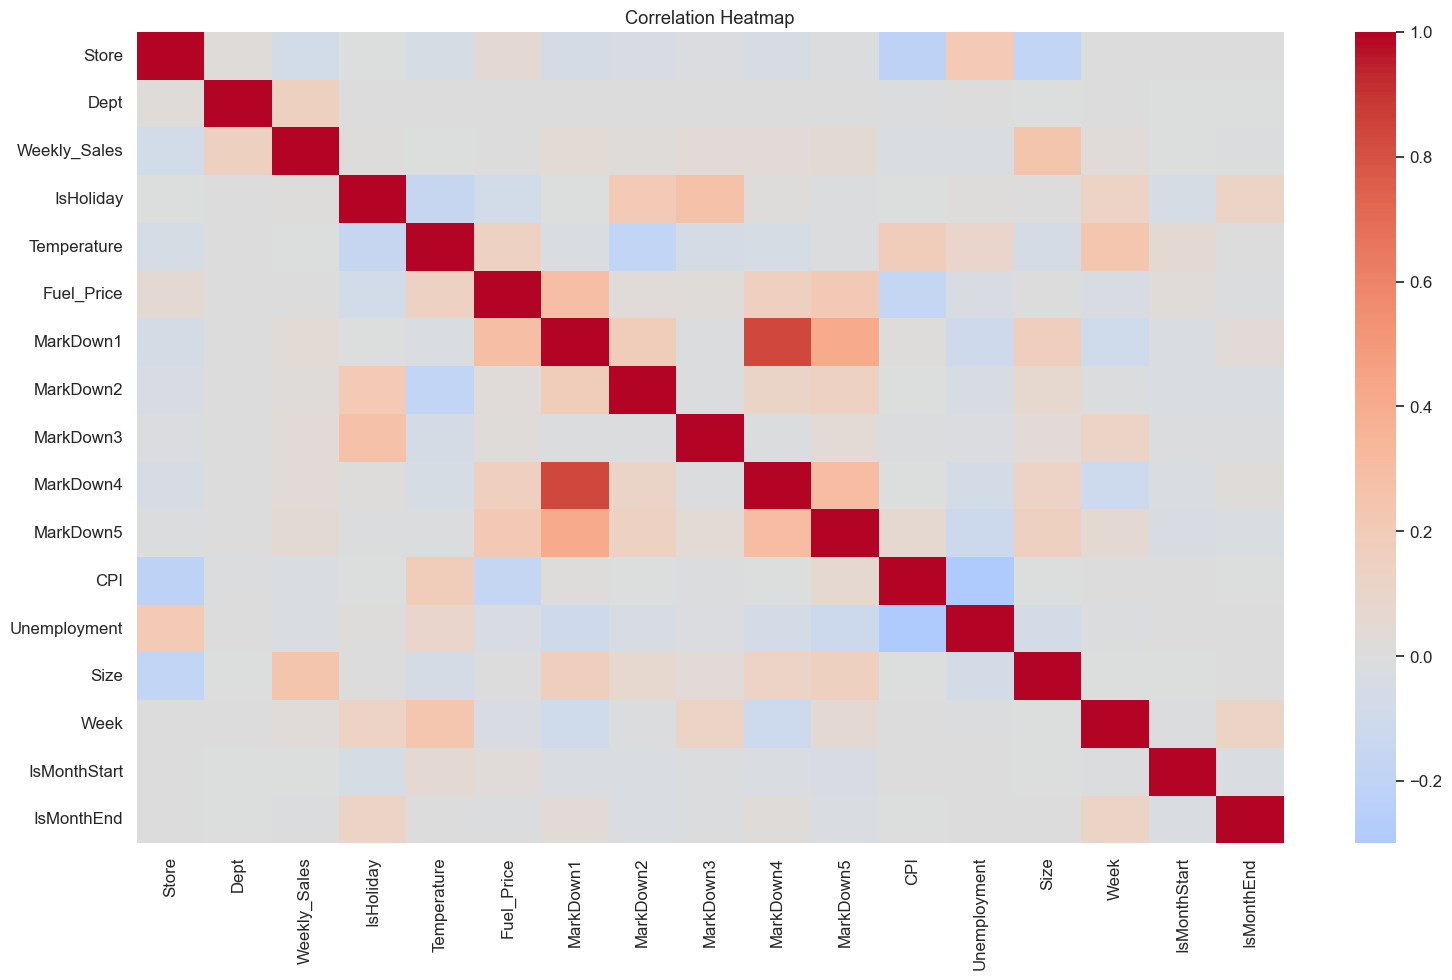

In [51]:
plt.figure(figsize=(16,10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

In [52]:
sales_corr = (
    correlation_matrix["Weekly_Sales"]
    .sort_values(ascending=False)
)

sales_corr

Weekly_Sales    1.000000
Size            0.243828
Dept            0.148032
MarkDown5       0.050465
MarkDown1       0.047172
MarkDown3       0.038562
MarkDown4       0.037467
Week            0.027673
MarkDown2       0.020716
IsHoliday       0.012774
Fuel_Price     -0.000120
Temperature    -0.002312
IsMonthStart   -0.004047
IsMonthEnd     -0.009319
CPI            -0.020921
Unemployment   -0.025864
Store          -0.085195
Name: Weekly_Sales, dtype: float64

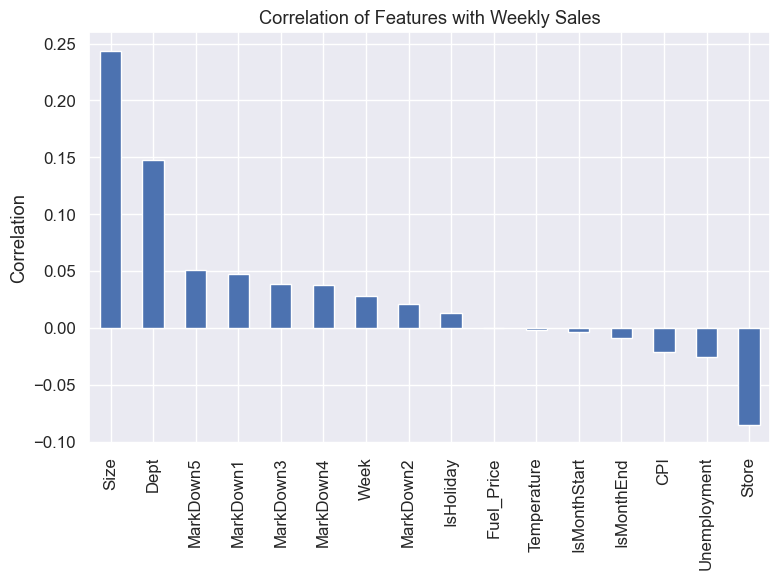

In [53]:
plt.figure(figsize=(8,6))

sales_corr.drop("Weekly_Sales").plot(kind="bar")

plt.title("Correlation of Features with Weekly Sales")

plt.ylabel("Correlation")

plt.tight_layout()

plt.show()

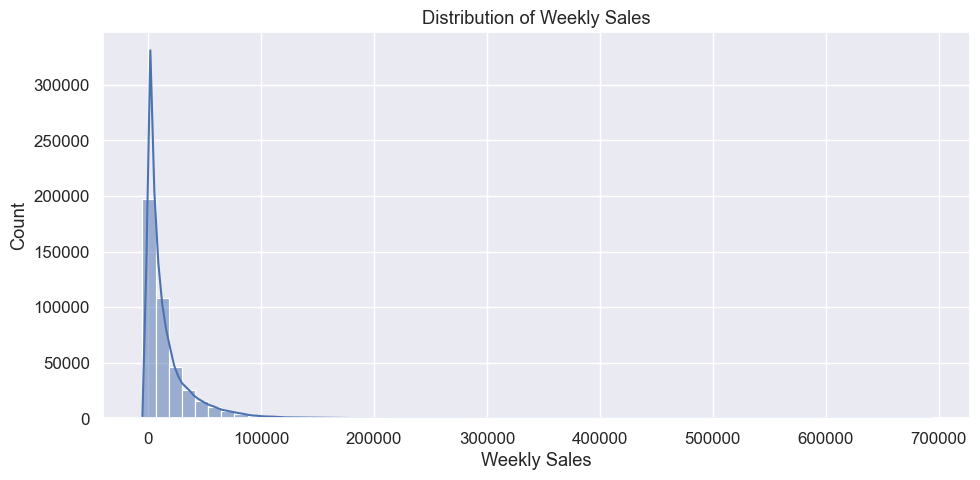

In [54]:
plt.figure(figsize=(10,5))

sns.histplot(
    train_df["Weekly_Sales"],
    bins=60,
    kde=True
)

plt.title("Distribution of Weekly Sales")

plt.xlabel("Weekly Sales")

plt.tight_layout()

plt.show()

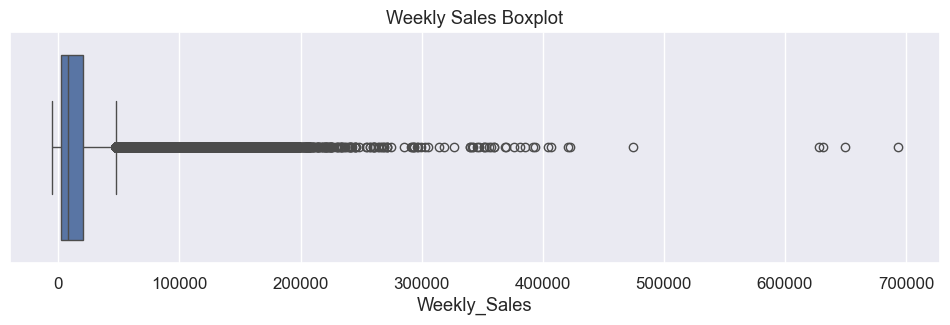

In [55]:
plt.figure(figsize=(12,3))

sns.boxplot(
    x=train_df["Weekly_Sales"]
)

plt.title("Weekly Sales Boxplot")

plt.show()

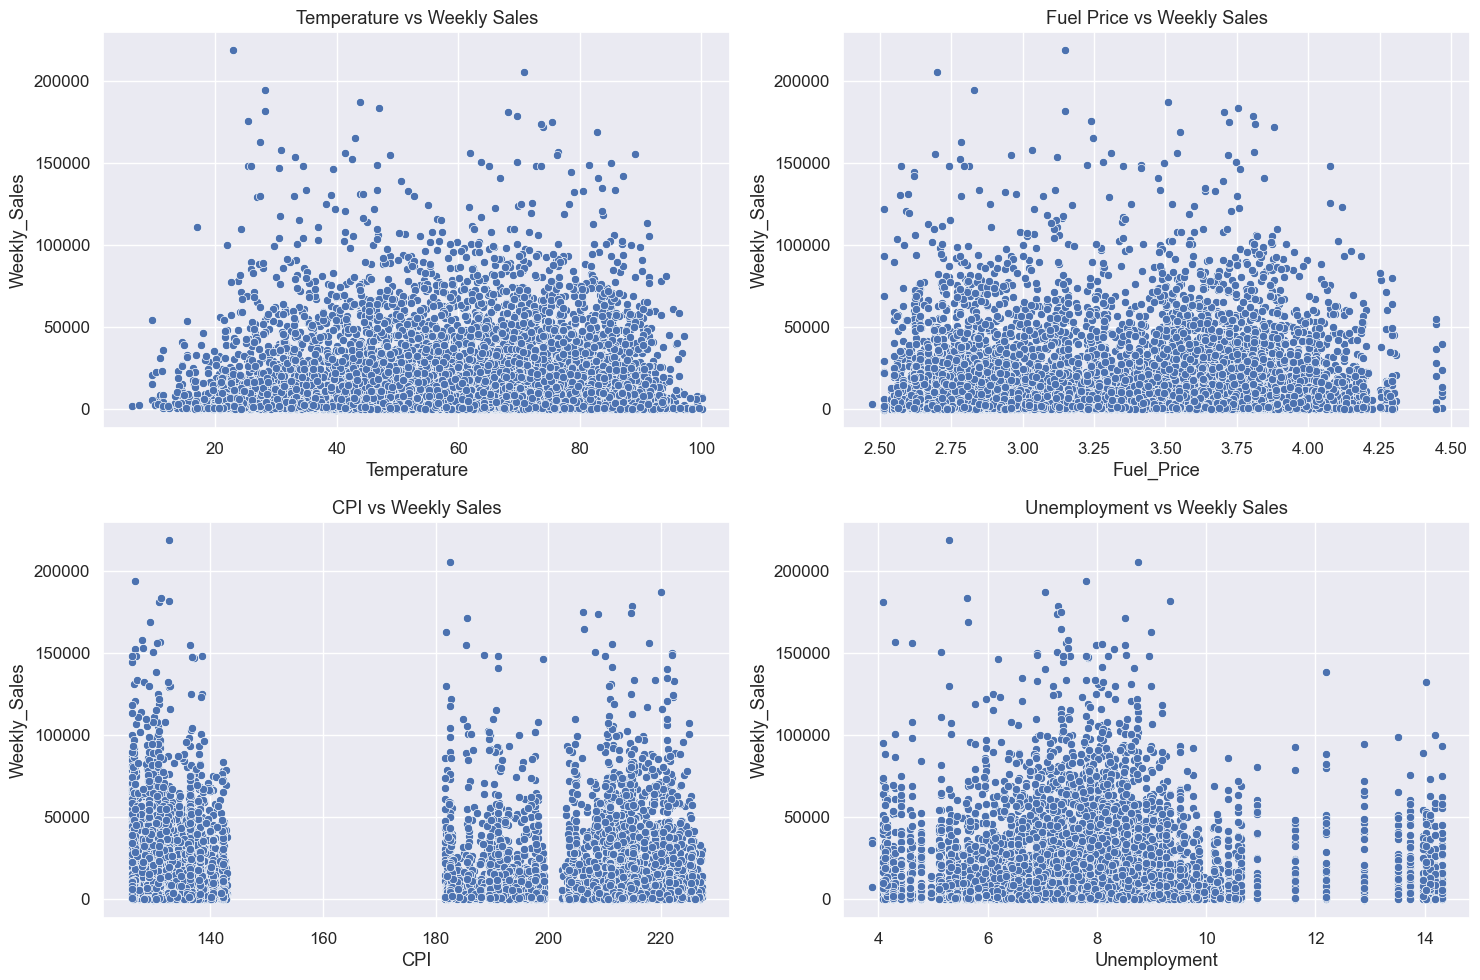

In [56]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

sns.scatterplot(
    data=train_df.sample(10000, random_state=42),
    x="Temperature",
    y="Weekly_Sales",
    ax=axes[0,0]
)

axes[0,0].set_title("Temperature vs Weekly Sales")

sns.scatterplot(
    data=train_df.sample(10000, random_state=42),
    x="Fuel_Price",
    y="Weekly_Sales",
    ax=axes[0,1]
)

axes[0,1].set_title("Fuel Price vs Weekly Sales")

sns.scatterplot(
    data=train_df.sample(10000, random_state=42),
    x="CPI",
    y="Weekly_Sales",
    ax=axes[1,0]
)

axes[1,0].set_title("CPI vs Weekly Sales")

sns.scatterplot(
    data=train_df.sample(10000, random_state=42),
    x="Unemployment",
    y="Weekly_Sales",
    ax=axes[1,1]
)

axes[1,1].set_title("Unemployment vs Weekly Sales")

plt.tight_layout()

plt.show()

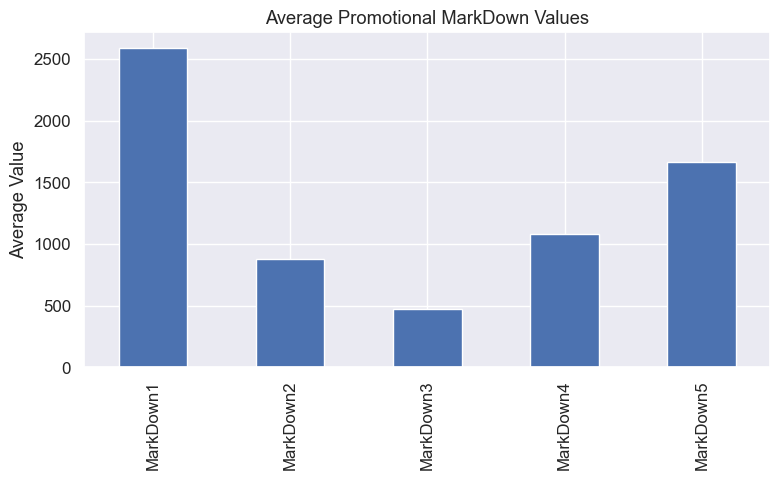

In [57]:
markdown_columns = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

markdown_means = train_df[markdown_columns].mean()

plt.figure(figsize=(8,5))

markdown_means.plot(kind="bar")

plt.title("Average Promotional MarkDown Values")

plt.ylabel("Average Value")

plt.tight_layout()

plt.show()

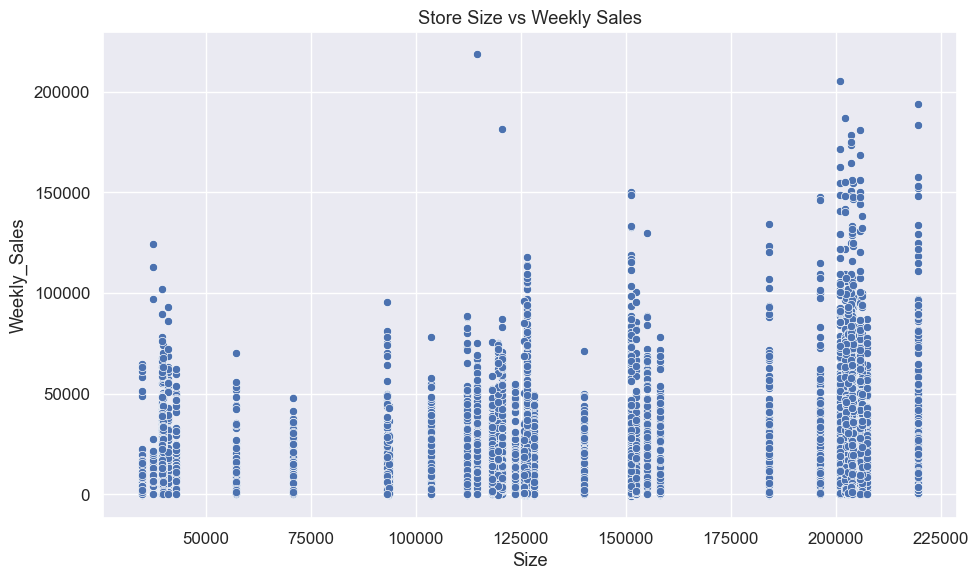

In [58]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=train_df.sample(10000, random_state=42),
    x="Size",
    y="Weekly_Sales"
)

plt.title("Store Size vs Weekly Sales")

plt.tight_layout()

plt.show()

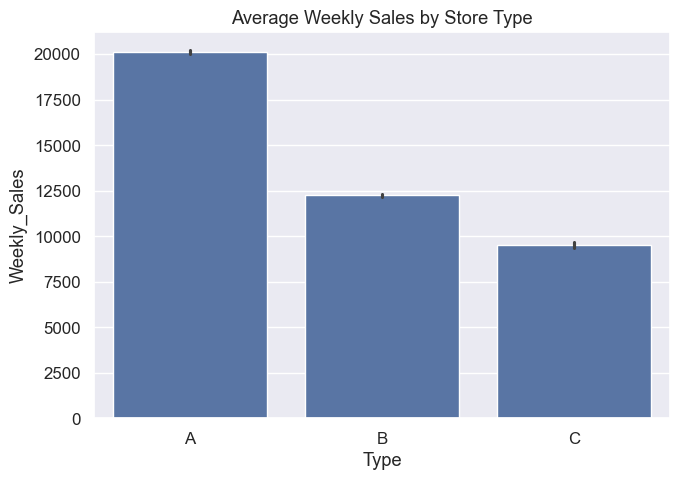

In [59]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=train_df,
    x="Type",
    y="Weekly_Sales",
    estimator="mean"
)

plt.title("Average Weekly Sales by Store Type")

plt.tight_layout()

plt.show()

In [60]:
# ==========================================================
# Sort Dataset
# ==========================================================

train_df = train_df.sort_values(
    by=["Store", "Dept", "Date"]
).reset_index(drop=True)

print("Dataset sorted successfully.")

Dataset sorted successfully.


In [61]:
# ==========================================================
# Lag Features
# ==========================================================

lag_periods = [1, 2, 4, 8, 12]

for lag in lag_periods:

    train_df[f"Lag_{lag}"] = (
        train_df
        .groupby(["Store", "Dept"])["Weekly_Sales"]
        .shift(lag)
    )

print("Lag Features Created")

Lag Features Created


In [62]:
# ==========================================================
# Rolling Statistics
# ==========================================================

rolling_windows = [4, 8]

for window in rolling_windows:

    train_df[f"RollingMean_{window}"] = (

        train_df

        .groupby(["Store", "Dept"])["Weekly_Sales"]

        .transform(
            lambda x:
            x.shift(1).rolling(window).mean()
        )

    )

    train_df[f"RollingStd_{window}"] = (

        train_df

        .groupby(["Store", "Dept"])["Weekly_Sales"]

        .transform(
            lambda x:
            x.shift(1).rolling(window).std()
        )

    )

print("Rolling Features Created")

Rolling Features Created


In [63]:
# ==========================================================
# Holiday Features
# ==========================================================

train_df["Holiday_Last_Week"] = (
    train_df
    .groupby(["Store","Dept"])["IsHoliday"]
    .shift(1)
)

train_df["Holiday_Next_Week"] = (
    train_df
    .groupby(["Store","Dept"])["IsHoliday"]
    .shift(-1)
)

holiday_columns = [
    "Holiday_Last_Week",
    "Holiday_Next_Week"
]

train_df[holiday_columns] = (
    train_df[holiday_columns]
    .fillna(0)
)

print("Holiday Features Created")

Holiday Features Created


In [64]:
# ==========================================================
# Promotion Features
# ==========================================================

markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

train_df["MarkDown_Total"] = train_df[
    markdown_cols
].sum(axis=1)

train_df["MarkDown_Holiday"] = (

    train_df["MarkDown_Total"]

    *

    train_df["IsHoliday"]

)

train_df["Temperature_Holiday"] = (

    train_df["Temperature"]

    *

    train_df["IsHoliday"]

)

train_df["Fuel_CPI"] = (

    train_df["Fuel_Price"]

    *

    train_df["CPI"]

)

train_df["StoreSize_MarkDown"] = (

    train_df["Size"]

    *

    train_df["MarkDown_Total"]

)

print("Interaction Features Created")

Interaction Features Created


In [65]:
# ==========================================================
# Encode Store Type
# ==========================================================

train_df["Type"] = train_df["Type"].map({
    "A":0,
    "B":1,
    "C":2
})

print("Store Type Encoded")

Store Type Encoded


In [66]:
# ==========================================================
# Handle Missing Values
# ==========================================================

feature_columns = [

    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Lag_8",
    "Lag_12",

    "RollingMean_4",
    "RollingMean_8",

    "RollingStd_4",
    "RollingStd_8",

    "Holiday_Last_Week",
    "Holiday_Next_Week"

]

train_df[feature_columns] = train_df[
    feature_columns
].fillna(0)

print("Missing Values Handled Successfully")

Missing Values Handled Successfully


In [67]:
# ==========================================================
# Verify Feature Engineering
# ==========================================================

print("Dataset Shape :", train_df.shape)

print("\nMissing Values :", train_df.isnull().sum().sum())

print("\nTotal Features :", train_df.shape[1])

train_df.head()

Dataset Shape : (421570, 41)

Missing Values : 0

Total Features : 41


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Quarter,Week,Day,DayOfWeek,DayOfYear,IsMonthStart,IsMonthEnd,Lag_1,Lag_2,Lag_4,Lag_8,Lag_12,RollingMean_4,RollingStd_4,RollingMean_8,RollingStd_8,Holiday_Last_Week,Holiday_Next_Week,MarkDown_Total,MarkDown_Holiday,Temperature_Holiday,Fuel_CPI,StoreSize_MarkDown
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0,151315,2010,2,1,5,5,4,36,0,0,0.00,0.00,0.0,0.0,0.0,0.00,0.000000,0.0,0.0,0.0,1.0,0.0,0.0,0.00,542.939833,0.0
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,0,151315,2010,2,1,6,12,4,43,0,0,24924.50,0.00,0.0,0.0,0.0,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,38.51,538.245049,0.0
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,0,151315,2010,2,1,7,19,4,50,0,0,46039.49,24924.50,0.0,0.0,0.0,0.00,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.00,531.180905,0.0
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,0,151315,2010,2,1,8,26,4,57,0,0,41595.55,46039.49,0.0,0.0,0.0,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00,541.189605,0.0
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,0,151315,2010,3,1,9,5,4,64,0,0,19403.54,41595.55,24924.5,0.0,0.0,32990.77,12832.106391,0.0,0.0,0.0,0.0,0.0,0.0,0.00,554.794125,0.0


# Model Data Preparation

In [68]:
# ==========================================================
# Dataset Information
# ==========================================================

print("Dataset Shape :", train_df.shape)

print("\nColumns:")

for column in train_df.columns:
    print(column)

Dataset Shape : (421570, 41)

Columns:
Store
Dept
Date
Weekly_Sales
IsHoliday
Temperature
Fuel_Price
MarkDown1
MarkDown2
MarkDown3
MarkDown4
MarkDown5
CPI
Unemployment
Type
Size
Year
Month
Quarter
Week
Day
DayOfWeek
DayOfYear
IsMonthStart
IsMonthEnd
Lag_1
Lag_2
Lag_4
Lag_8
Lag_12
RollingMean_4
RollingStd_4
RollingMean_8
RollingStd_8
Holiday_Last_Week
Holiday_Next_Week
MarkDown_Total
MarkDown_Holiday
Temperature_Holiday
Fuel_CPI
StoreSize_MarkDown


In [69]:
# ==========================================================
# Feature Selection
# ==========================================================

drop_columns = [
    "Weekly_Sales",   # Target variable
    "Date"            # Raw date column (date-based features already created)
]

X = train_df.drop(columns=drop_columns)

y = train_df["Weekly_Sales"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (421570, 39)
Target Shape : (421570,)


In [70]:
# ==========================================================
# Features Used for Training
# ==========================================================

print("Input Features:\n")

for feature in X.columns:
    print(feature)

Input Features:

Store
Dept
IsHoliday
Temperature
Fuel_Price
MarkDown1
MarkDown2
MarkDown3
MarkDown4
MarkDown5
CPI
Unemployment
Type
Size
Year
Month
Quarter
Week
Day
DayOfWeek
DayOfYear
IsMonthStart
IsMonthEnd
Lag_1
Lag_2
Lag_4
Lag_8
Lag_12
RollingMean_4
RollingStd_4
RollingMean_8
RollingStd_8
Holiday_Last_Week
Holiday_Next_Week
MarkDown_Total
MarkDown_Holiday
Temperature_Holiday
Fuel_CPI
StoreSize_MarkDown


In [71]:
# ==========================================================
# Sort Data by Date
# ==========================================================

model_data = train_df.sort_values("Date").reset_index(drop=True)

X = model_data.drop(columns=["Weekly_Sales", "Date"])
y = model_data["Weekly_Sales"]

print("Data sorted chronologically.")

Data sorted chronologically.


In [72]:
# ==========================================================
# Time-Series Train-Validation Split
# ==========================================================

split_index = int(len(model_data) * 0.80)

X_train = X.iloc[:split_index]
X_valid = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_valid = y.iloc[split_index:]

print("Training Samples :", len(X_train))
print("Validation Samples :", len(X_valid))

Training Samples : 337256
Validation Samples : 84314


In [73]:
# ==========================================================
# Verify Time Split
# ==========================================================

print("Training Period")
print(model_data.iloc[:split_index]["Date"].min())
print(model_data.iloc[:split_index]["Date"].max())

print("\nValidation Period")
print(model_data.iloc[split_index:]["Date"].min())
print(model_data.iloc[split_index:]["Date"].max())

Training Period
2010-02-05 00:00:00
2012-04-13 00:00:00

Validation Period
2012-04-13 00:00:00
2012-10-26 00:00:00


In [74]:
# ==========================================================
# Final Dataset Check
# ==========================================================

print("=" * 60)

print("Training Feature Shape :", X_train.shape)
print("Validation Feature Shape :", X_valid.shape)

print("Training Target Shape :", y_train.shape)
print("Validation Target Shape :", y_valid.shape)

print("=" * 60)

Training Feature Shape : (337256, 39)
Validation Feature Shape : (84314, 39)
Training Target Shape : (337256,)
Validation Target Shape : (84314,)


# Baseline Model (Linear Regression)

In [75]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import os
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [76]:
# ==========================================================
# Create Output Folder
# ==========================================================

os.makedirs("outputs", exist_ok=True)

print("Output folder is ready.")

Output folder is ready.


In [77]:
# ==========================================================
# One-Hot Encode Categorical Features
# ==========================================================

# Ensure Type is treated as string before encoding
train_df["Type"] = train_df["Type"].astype(str)

# One-Hot Encode Store Type
train_df = pd.get_dummies(
    train_df,
    columns=["Type"],
    prefix="StoreType",
    drop_first=True
)

print("One-Hot Encoding Completed.")
print(train_df.filter(like="StoreType").head())

One-Hot Encoding Completed.
   StoreType_1  StoreType_2
0        False        False
1        False        False
2        False        False
3        False        False
4        False        False


In [78]:
# ==========================================================
# Select Input Features and Target
# ==========================================================

drop_columns = [
    "Weekly_Sales",
    "Date"
]

X = train_df.drop(columns=drop_columns)
y = train_df["Weekly_Sales"]

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Shape         : {y.shape}")

Feature Matrix Shape : (421570, 40)
Target Shape         : (421570,)


In [79]:
# ==========================================================
# Scale Numerical Features
# ==========================================================

scaler = StandardScaler()

numeric_columns = X.select_dtypes(include=["int64", "float64"]).columns

X[numeric_columns] = scaler.fit_transform(X[numeric_columns])

print("Numerical Features Scaled Successfully.")

Numerical Features Scaled Successfully.


In [80]:
# ==========================================================
# Final Verification
# ==========================================================

print("=" * 60)
print("Final Dataset Ready for Modeling")
print("=" * 60)

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Shape         : {y.shape}")
print(f"Missing Values       : {X.isnull().sum().sum()}")

print("\nFeature Data Types:")
print(X.dtypes.value_counts())

Final Dataset Ready for Modeling
Feature Matrix Shape : (421570, 40)
Target Shape         : (421570,)
Missing Values       : 0

Feature Data Types:
float64    32
int32       6
bool        2
Name: count, dtype: int64


In [81]:
# ==========================================================
# Preview Processed Features
# ==========================================================

X.head()

,Store,Dept,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Year,Month,Quarter,Week,Day,DayOfWeek,DayOfYear,IsMonthStart,IsMonthEnd,Lag_1,Lag_2,Lag_4,Lag_8,Lag_12,RollingMean_4,RollingStd_4,RollingMean_8,RollingStd_8,Holiday_Last_Week,Holiday_Next_Week,MarkDown_Total,MarkDown_Holiday,Temperature_Holiday,Fuel_CPI,StoreSize_MarkDown,StoreType_1,StoreType_2
0,-1.658199,-1.418742,-0.275106,-0.963798,-1.720834,-0.427943,-0.173069,-0.084662,-0.278117,-0.395181,1.018774,0.078201,0.239209,2010,2,1,-1.471661,5,4,36,-0.1694,-0.169518,-0.699834,-0.696084,-0.688696,-0.674159,-0.659092,-0.704295,-0.377233,-0.694864,-0.422288,-0.274976,3.640641,-0.453127,-0.135351,-0.253772,-0.207828,-0.411467,False,False
1,-1.658199,-1.418742,3.634961,-1.169783,-1.773177,-0.427943,-0.173069,-0.084662,-0.278117,-0.395181,1.022498,0.078201,0.239209,2010,2,1,-1.400999,12,4,43,-0.1694,-0.169518,0.399064,-0.696084,-0.688696,-0.674159,-0.659092,-0.704295,-0.377233,-0.694864,-0.422288,-0.274976,-0.274677,-0.453127,-0.135351,2.544788,-0.240873,-0.411467,False,False
2,-1.658199,-1.418742,-0.275106,-1.092810,-1.847330,-0.427943,-0.173069,-0.084662,-0.278117,-0.395181,1.023697,0.078201,0.239209,2010,2,1,-1.330337,19,4,50,-0.1694,-0.169518,1.330004,0.404351,-0.688696,-0.674159,-0.659092,-0.704295,-0.377233,-0.694864,-0.422288,3.636676,-0.274677,-0.453127,-0.135351,-0.253772,-0.290596,-0.411467,False,False
3,-1.658199,-1.418742,-0.275106,-0.729625,-1.744825,-0.427943,-0.173069,-0.084662,-0.278117,-0.395181,1.024476,0.078201,0.239209,2010,2,1,-1.259675,26,4,57,-0.1694,-0.169518,1.134075,1.336593,-0.688696,-0.674159,-0.659092,-0.704295,-0.377233,-0.694864,-0.422288,-0.274976,-0.274677,-0.453127,-0.135351,-0.253772,-0.220147,-0.411467,False,False
4,-1.658199,-1.418742,-0.275106,-0.736672,-1.605243,-0.427943,-0.173069,-0.084662,-0.278117,-0.395181,1.025255,0.078201,0.239209,2010,3,1,-1.189013,5,4,64,-0.1694,-0.169518,0.155650,1.140390,0.415629,-0.674159,-0.659092,0.791348,2.151436,-0.694864,-0.422288,-0.274976,-0.274677,-0.453127,-0.135351,-0.253772,-0.124388,-0.411467,False,False


# Baseline Model (Linear Regression)

In [82]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [83]:
# ==========================================================
# Weighted Mean Absolute Error (WMAE)
# ==========================================================

def weighted_mae(y_true, y_pred, is_holiday):
    """
    Calculates Weighted Mean Absolute Error (WMAE).

    Holiday weeks receive 5x weight
    Non-holiday weeks receive 1x weight
    """

    weights = np.where(is_holiday == 1, 5, 1)

    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

print("WMAE Function Created Successfully.")

WMAE Function Created Successfully.


In [84]:
# ==========================================================
# Initialize TimeSeriesSplit
# ==========================================================

tscv = TimeSeriesSplit(
    n_splits=5
)

print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


In [85]:
# ==========================================================
# Initialize Metric Storage
# ==========================================================

mae_scores = []
rmse_scores = []
mape_scores = []
r2_scores = []
wmae_scores = []

fold_results = []

print("Metric Containers Created Successfully.")

Metric Containers Created Successfully.


In [86]:
# ==========================================================
# Verify Dataset Before Training
# ==========================================================

print("=" * 60)
print("Dataset Ready for Linear Regression")
print("=" * 60)

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Shape         : {y.shape}")

print("\nMissing Values")

print(X.isnull().sum().sum())

print("\nTarget Statistics")

print(y.describe())

Dataset Ready for Linear Regression
Feature Matrix Shape : (421570, 40)
Target Shape         : (421570,)

Missing Values
0

Target Statistics
count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64


In [87]:
# ==========================================================
# Verify TimeSeriesSplit
# ==========================================================

fold = 1

for train_index, test_index in tscv.split(X):

    print("-" * 50)

    print(f"Fold {fold}")

    print(f"Training Samples : {len(train_index)}")

    print(f"Validation Samples : {len(test_index)}")

    fold += 1

--------------------------------------------------
Fold 1
Training Samples : 70265
Validation Samples : 70261
--------------------------------------------------
Fold 2
Training Samples : 140526
Validation Samples : 70261
--------------------------------------------------
Fold 3
Training Samples : 210787
Validation Samples : 70261
--------------------------------------------------
Fold 4
Training Samples : 281048
Validation Samples : 70261
--------------------------------------------------
Fold 5
Training Samples : 351309
Validation Samples : 70261


In [88]:
# ==========================================================
# Check Feature Data Types
# ==========================================================

print(X.dtypes.value_counts())

print("\nNon-Numeric Columns:")

non_numeric = X.select_dtypes(exclude=["int64", "float64", "uint8", "bool"])

print(non_numeric.columns.tolist())

float64    32
int32       6
bool        2
Name: count, dtype: int64

Non-Numeric Columns:
['Year', 'Month', 'Quarter', 'Day', 'DayOfWeek', 'DayOfYear']


In [89]:
# ==========================================================
# Convert Date Features to Integer
# ==========================================================

date_columns = [
    "Year",
    "Month",
    "Quarter",
    "Day",
    "DayOfWeek",
    "DayOfYear"
]

for col in date_columns:
    X[col] = X[col].astype("int32")

print("Date feature data types updated successfully.")

Date feature data types updated successfully.


In [90]:
print(X.dtypes.value_counts())

print("\nNon-Numeric Columns:")

non_numeric = X.select_dtypes(exclude=["int64", "int32", "float64", "uint8", "bool"])

print(non_numeric.columns.tolist())

float64    32
int32       6
bool        2
Name: count, dtype: int64

Non-Numeric Columns:
[]


In [91]:
# ==========================================================
# Initialize Linear Regression Model
# ==========================================================

linear_model = LinearRegression()

print("Linear Regression Model Initialized Successfully.")

Linear Regression Model Initialized Successfully.


In [92]:
# ==========================================================
# Train Linear Regression using TimeSeriesSplit
# ==========================================================

fold = 1

best_rmse = float("inf")
best_predictions = None
best_actual = None
best_features = None
best_fold = None

for train_index, test_index in tscv.split(X):

    print("=" * 70)
    print(f"Training Fold {fold}")
    print("=" * 70)

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # Train Model
    linear_model.fit(X_train, y_train)

    # Predict
    y_pred = linear_model.predict(X_test)

    # Evaluation Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # WMAE
    wmae = weighted_mae(
        y_test.values,
        y_pred,
        X_test["IsHoliday"].values
    )

    # Store Metrics
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    mape_scores.append(mape)
    r2_scores.append(r2)
    wmae_scores.append(wmae)

    fold_results.append({
        "Fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2,
        "WMAE": wmae
    })

    # Save Best Fold
    if rmse < best_rmse:
        best_rmse = rmse
        best_predictions = y_pred
        best_actual = y_test
        best_features = X_test
        best_fold = fold

    print(f"MAE   : {mae:,.2f}")
    print(f"RMSE  : {rmse:,.2f}")
    print(f"MAPE  : {mape:.4f}")
    print(f"R²    : {r2:.4f}")
    print(f"WMAE  : {wmae:,.2f}")

    fold += 1

Training Fold 1
MAE   : 2,969.39
RMSE  : 8,256.94
MAPE  : 1843855196120489.7500
R²    : 0.9061
WMAE  : 2,969.39
Training Fold 2
MAE   : 2,585.21
RMSE  : 6,581.10
MAPE  : 1758132502448143.2500
R²    : 0.9078
WMAE  : 2,585.21
Training Fold 3
MAE   : 2,640.42
RMSE  : 6,791.24
MAPE  : 639329910042649.6250
R²    : 0.9042
WMAE  : 2,640.42
Training Fold 4
MAE   : 1,882.35
RMSE  : 5,512.28
MAPE  : 518739268582010.0625
R²    : 0.9101
WMAE  : 1,882.35
Training Fold 5
MAE   : 1,857.24
RMSE  : 4,764.69
MAPE  : 849924374719037.8750
R²    : 0.9393
WMAE  : 1,857.24


In [93]:
# ==========================================================
# Fold-wise Performance
# ==========================================================

fold_results_df = pd.DataFrame(fold_results)

fold_results_df

,Fold,MAE,RMSE,MAPE,R2,WMAE
0,1,2969.387724,8256.940062,1.843855e+15,0.906108,2969.387724
1,2,2585.205308,6581.097964,1.758133e+15,0.907847,2585.205308
2,3,2640.418420,6791.236967,6.393299e+14,0.904208,2640.418420
3,4,1882.351977,5512.278096,5.187393e+14,0.910120,1882.351977
4,5,1857.242542,4764.691702,8.499244e+14,0.939312,1857.242542


In [94]:
# ==========================================================
# Average Performance
# ==========================================================

baseline_results = pd.DataFrame({

    "Metric":[
        "MAE",
        "RMSE",
        "MAPE",
        "R2",
        "WMAE"
    ],

    "Linear Regression":[

        np.mean(mae_scores),

        np.mean(rmse_scores),

        np.mean(mape_scores),

        np.mean(r2_scores),

        np.mean(wmae_scores)

    ]

})

baseline_results

,Metric,Linear Regression
0,MAE,2.386921e+03
1,RMSE,6.381249e+03
2,MAPE,1.121996e+15
3,R2,9.135190e-01
4,WMAE,2.386921e+03


In [95]:
# ==========================================================
# Save Results
# ==========================================================

baseline_results.to_csv(
    "outputs/linear_regression_results.csv",
    index=False
)

fold_results_df.to_csv(
    "outputs/linear_regression_fold_results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


In [96]:
# ==========================================================
# Create Residual DataFrame
# ==========================================================

residual_df = pd.DataFrame({
    "Actual": best_actual.values,
    "Predicted": best_predictions
})

residual_df["Residual"] = (
    residual_df["Actual"] -
    residual_df["Predicted"]
)

print(residual_df.head())

    Actual    Predicted     Residual
0  1053.86   781.695827   272.164173
1  1246.77   660.245221   586.524779
2   778.70  4534.403430 -3755.703430
3   647.65  1640.491691  -992.841691
4   514.74  -337.925976   852.665976


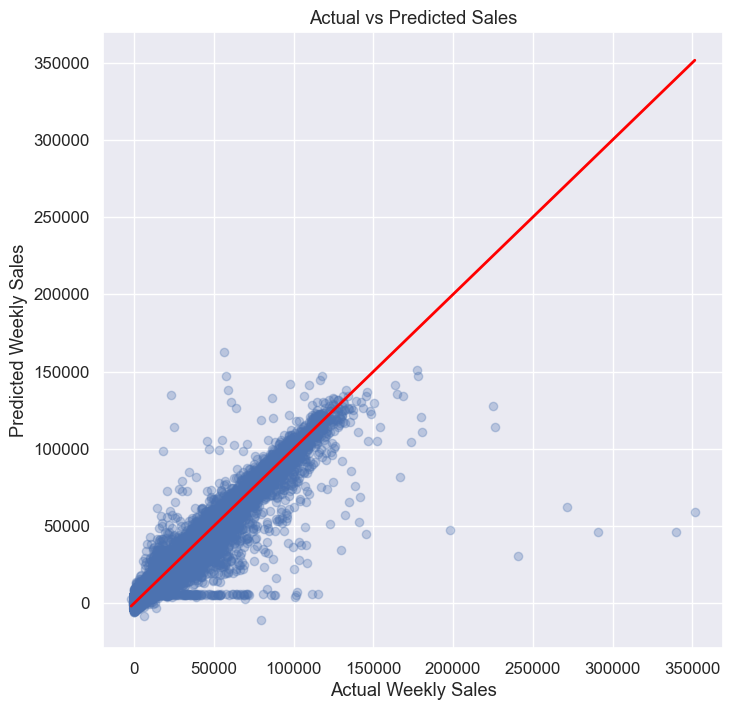

In [97]:
# ==========================================================
# Actual vs Predicted Sales
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.scatter(
    residual_df["Actual"],
    residual_df["Predicted"],
    alpha=0.3
)

plt.plot(
    [
        residual_df["Actual"].min(),
        residual_df["Actual"].max()
    ],
    [
        residual_df["Actual"].min(),
        residual_df["Actual"].max()
    ],
    color="red",
    linewidth=2
)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Actual Weekly Sales")

plt.ylabel("Predicted Weekly Sales")

plt.show()

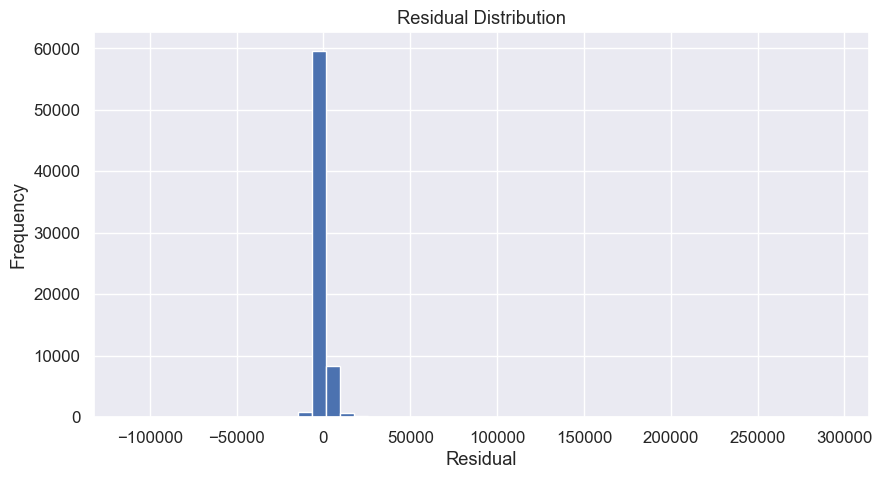

In [98]:
# ==========================================================
# Residual Distribution
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(
    residual_df["Residual"],
    bins=50
)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.show()

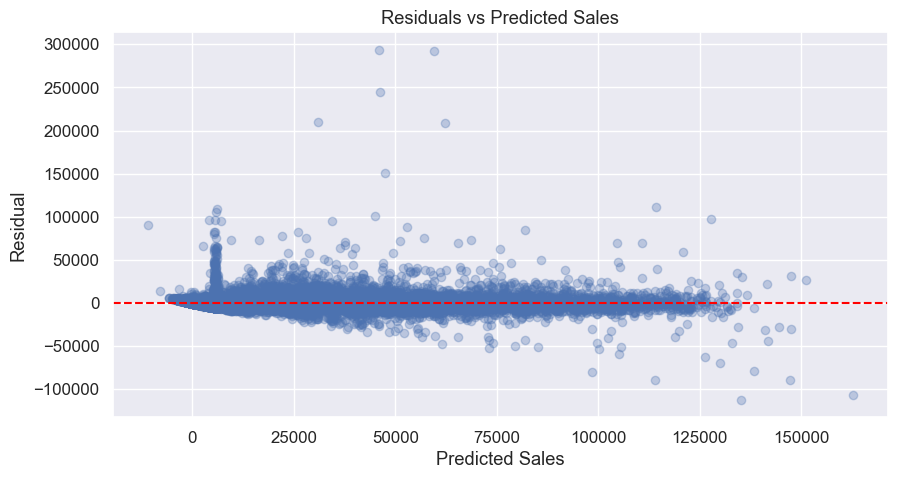

In [99]:
# ==========================================================
# Residuals vs Predicted
# ==========================================================

plt.figure(figsize=(10,5))

plt.scatter(
    residual_df["Predicted"],
    residual_df["Residual"],
    alpha=0.3
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residuals vs Predicted Sales")

plt.xlabel("Predicted Sales")

plt.ylabel("Residual")

plt.show()

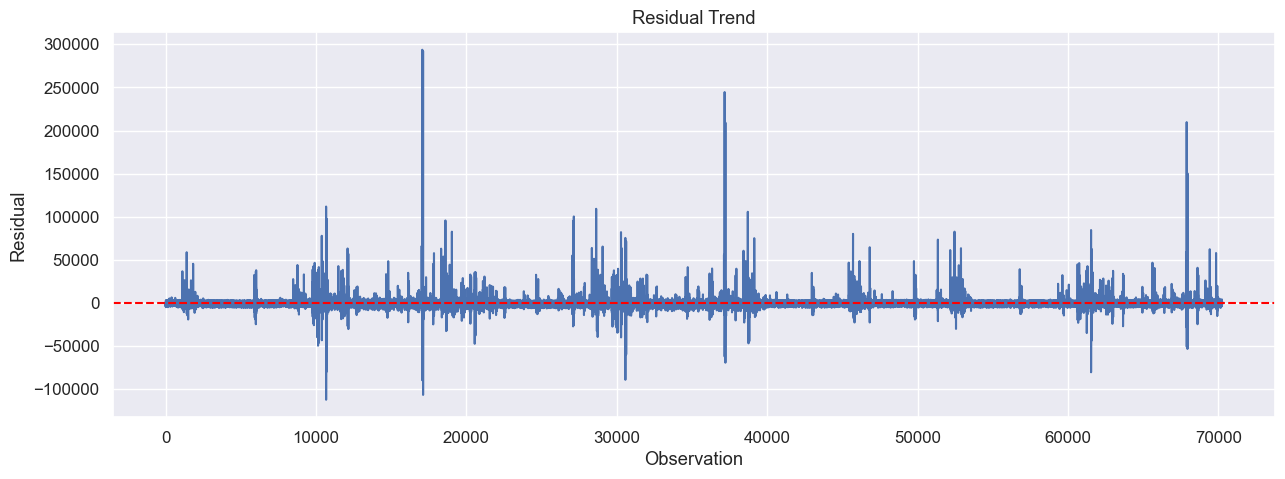

In [100]:
# ==========================================================
# Residual Trend
# ==========================================================

plt.figure(figsize=(15,5))

plt.plot(
    residual_df["Residual"].values
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Residual Trend")

plt.xlabel("Observation")

plt.ylabel("Residual")

plt.show()

In [101]:
# ==========================================================
# Residual Statistics
# ==========================================================

print("="*60)

print("Residual Statistics")

print("="*60)

print(residual_df["Residual"].describe())

Residual Statistics
count     70261.000000
mean         69.253940
std        4764.222283
min     -112065.592621
25%       -1024.673794
50%         -89.531959
75%         733.490957
max      293712.266185
Name: Residual, dtype: float64


In [102]:
# ==========================================================
# Sample Predictions
# ==========================================================

comparison_df = pd.DataFrame({

    "Actual": best_actual.values,

    "Predicted": best_predictions,

    "Residual": residual_df["Residual"]

})

comparison_df.head(20)

,Actual,Predicted,Residual
0,1053.86,781.695827,272.164173
1,1246.77,660.245221,586.524779
2,778.70,4534.403430,-3755.703430
3,647.65,1640.491691,-992.841691
4,514.74,-337.925976,852.665976
5,823.15,1090.985391,-267.835391
6,525.76,731.340697,-205.580697
7,517.03,1087.029574,-569.999574
8,364.92,816.365809,-451.445809
9,741.65,662.599487,79.050513


In [103]:
# ==========================================================
# Save Residual Data
# ==========================================================

comparison_df.to_csv(
    "outputs/linear_regression_predictions.csv",
    index=False
)

print("Prediction results saved successfully.")

Prediction results saved successfully.


# XGBoost

In [104]:
from xgboost import XGBRegressor

In [105]:
# ==========================================================
# Initialize XGBoost Model
# ==========================================================

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

print(xgb_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)


In [106]:
# ==========================================================
# Train & Evaluate XGBoost using TimeSeriesSplit
# ==========================================================

xgb_results = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    wmae = weighted_mae(
        y_test.values,
        y_pred,
        X_test["IsHoliday"].values
    )

    xgb_results.append({
        "Fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2,
        "WMAE": wmae
    })

    print(f"\nFold {fold}")
    print(f"MAE  : {mae:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"WMAE : {wmae:,.2f}")


Fold 1
MAE  : 2,132.39
RMSE : 6,321.68
MAPE : 714675753935204.3750
R²   : 0.9450
WMAE : 2,132.39

Fold 2
MAE  : 1,761.96
RMSE : 4,508.77
MAPE : 1532293531225618.5000
R²   : 0.9567
WMAE : 1,761.96

Fold 3
MAE  : 1,853.14
RMSE : 4,373.58
MAPE : 99965901808571.0156
R²   : 0.9603
WMAE : 1,853.14

Fold 4
MAE  : 1,325.71
RMSE : 3,975.54
MAPE : 169398704019922.6875
R²   : 0.9532
WMAE : 1,325.71

Fold 5
MAE  : 1,197.69
RMSE : 3,175.76
MAPE : 124023506030828.5000
R²   : 0.9730
WMAE : 1,197.69


In [107]:
# ==========================================================
# Average Performance
# ==========================================================

xgb_results_df = pd.DataFrame(xgb_results)

display(xgb_results_df)

print("\nAverage Performance")

print(f"MAE  : {xgb_results_df['MAE'].mean():,.2f}")
print(f"RMSE : {xgb_results_df['RMSE'].mean():,.2f}")
print(f"MAPE : {xgb_results_df['MAPE'].mean():.4f}")
print(f"R²   : {xgb_results_df['R2'].mean():.4f}")
print(f"WMAE : {xgb_results_df['WMAE'].mean():,.2f}")

,Fold,MAE,RMSE,MAPE,R2,WMAE
0,1,2132.385513,6321.675456,7.146758e+14,0.944963,2132.385513
1,2,1761.956878,4508.772177,1.532294e+15,0.956746,1761.956878
2,3,1853.135884,4373.579389,9.996590e+13,0.960271,1853.135884
3,4,1325.713836,3975.539192,1.693987e+14,0.953249,1325.713836
4,5,1197.690269,3175.759119,1.240235e+14,0.973039,1197.690269



Average Performance
MAE  : 1,654.18
RMSE : 4,471.07
MAPE : 528071479404029.0000
R²   : 0.9577
WMAE : 1,654.18


In [108]:
# ==========================================================
# Save Results
# ==========================================================

xgb_results_df.to_csv(
    "outputs/xgboost_results.csv",
    index=False
)

print("XGBoost Results Saved Successfully.")

XGBoost Results Saved Successfully.


In [110]:
# ==========================================================
# Import Libraries
# ==========================================================

from sklearn.model_selection import RandomizedSearchCV

print("RandomizedSearchCV Imported Successfully.")

RandomizedSearchCV Imported Successfully.


In [111]:
# ==========================================================
# Hyperparameter Search Space
# ==========================================================

param_grid = {

    "n_estimators": [100, 200, 300],

    "max_depth": [4, 6, 8, 10],

    "learning_rate": [0.01, 0.05, 0.1],

    "subsample": [0.8, 0.9, 1.0],

    "colsample_bytree": [0.8, 0.9, 1.0]

}

print(param_grid)

{'n_estimators': [100, 200, 300], 'max_depth': [4, 6, 8, 10], 'learning_rate': [0.01, 0.05, 0.1], 'subsample': [0.8, 0.9, 1.0], 'colsample_bytree': [0.8, 0.9, 1.0]}


In [113]:
# ==========================================================
# Hyperparameter Tuning
# ==========================================================

random_search = RandomizedSearchCV(

    estimator=xgb_model,

    param_distributions=param_grid,

    n_iter=10,

    scoring="neg_mean_absolute_error",

    cv=tscv,

    verbose=2,

    random_state=42,

    n_jobs=-1

)

random_search.fit(X, y)

print("Hyperparameter Tuning Completed.")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Hyperparameter Tuning Completed.


In [114]:
# ==========================================================
# Best Parameters
# ==========================================================

print("Best Parameters")

print(random_search.best_params_)

print("\nBest Score")

print(random_search.best_score_)

Best Parameters
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Best Score
-1752.0997823898592


In [115]:
# ==========================================================
# Best XGBoost Model
# ==========================================================

best_xgb_model = random_search.best_estimator_

print(best_xgb_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)


In [116]:
# ==========================================================
# Evaluate Tuned XGBoost Model
# ==========================================================

tuned_results = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    best_xgb_model.fit(X_train, y_train)

    predictions = best_xgb_model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    mape = mean_absolute_percentage_error(y_test, predictions)

    r2 = r2_score(y_test, predictions)

    wmae = weighted_mae(
        y_test.values,
        predictions,
        X_test["IsHoliday"].values
    )

    tuned_results.append({

        "Fold": fold,

        "MAE": mae,

        "RMSE": rmse,

        "MAPE": mape,

        "R2": r2,

        "WMAE": wmae

    })

tuned_results_df = pd.DataFrame(tuned_results)

display(tuned_results_df)

,Fold,MAE,RMSE,MAPE,R2,WMAE
0,1,2157.657164,6449.269482,7.043465e+14,0.942719,2157.657164
1,2,1843.019013,4551.602499,1.355489e+15,0.955920,1843.019013
2,3,1963.324731,4592.517669,1.884647e+14,0.956194,1963.324731
3,4,1502.899093,4195.711067,3.323652e+14,0.947927,1502.899093
4,5,1293.598911,3514.279473,1.329039e+14,0.966985,1293.598911


In [117]:
# ==========================================================
# Average Performance
# ==========================================================

print("=" * 60)
print("Tuned XGBoost Performance")
print("=" * 60)

print(f"Average MAE  : {tuned_results_df['MAE'].mean():,.2f}")

print(f"Average RMSE : {tuned_results_df['RMSE'].mean():,.2f}")

print(f"Average MAPE : {tuned_results_df['MAPE'].mean():.4f}")

print(f"Average R²   : {tuned_results_df['R2'].mean():.4f}")

print(f"Average WMAE : {tuned_results_df['WMAE'].mean():,.2f}")

Tuned XGBoost Performance
Average MAE  : 1,752.10
Average RMSE : 4,660.68
Average MAPE : 542713897644105.6875
Average R²   : 0.9539
Average WMAE : 1,752.10


In [118]:
# ==========================================================
# Average Performance
# ==========================================================

print("=" * 60)
print("Tuned XGBoost Performance")
print("=" * 60)

print(f"Average MAE  : {tuned_results_df['MAE'].mean():,.2f}")

print(f"Average RMSE : {tuned_results_df['RMSE'].mean():,.2f}")

print(f"Average MAPE : {tuned_results_df['MAPE'].mean():.4f}")

print(f"Average R²   : {tuned_results_df['R2'].mean():.4f}")

print(f"Average WMAE : {tuned_results_df['WMAE'].mean():,.2f}")

Tuned XGBoost Performance
Average MAE  : 1,752.10
Average RMSE : 4,660.68
Average MAPE : 542713897644105.6875
Average R²   : 0.9539
Average WMAE : 1,752.10


# Random Forest

In [119]:
# ==========================================================
# Import Random Forest
# ==========================================================

from sklearn.ensemble import RandomForestRegressor

print("Random Forest Imported Successfully.")

Random Forest Imported Successfully.


In [120]:
# ==========================================================
# Initialize Random Forest Model
# ==========================================================

rf_model = RandomForestRegressor(

    n_estimators=200,

    max_depth=15,

    random_state=42,

    n_jobs=-1

)

print(rf_model)

RandomForestRegressor(max_depth=15, n_estimators=200, n_jobs=-1,
                      random_state=42)


In [121]:
# ==========================================================
# Train Random Forest using TimeSeriesSplit
# ==========================================================

rf_results = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    rf_model.fit(X_train, y_train)

    predictions = rf_model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    mape = mean_absolute_percentage_error(y_test, predictions)

    r2 = r2_score(y_test, predictions)

    wmae = weighted_mae(
        y_test.values,
        predictions,
        X_test["IsHoliday"].values
    )

    rf_results.append({

        "Fold": fold,

        "MAE": mae,

        "RMSE": rmse,

        "MAPE": mape,

        "R2": r2,

        "WMAE": wmae

    })

    print(f"\nFold {fold}")

    print(f"MAE  : {mae:,.2f}")

    print(f"RMSE : {rmse:,.2f}")

    print(f"MAPE : {mape:.4f}")

    print(f"R²   : {r2:.4f}")

    print(f"WMAE : {wmae:,.2f}")


Fold 1
MAE  : 2,211.06
RMSE : 6,588.45
MAPE : 163962674455644.6250
R²   : 0.9402
WMAE : 2,211.06

Fold 2
MAE  : 1,854.64
RMSE : 5,092.85
MAPE : 1802038078792237.7500
R²   : 0.9448
WMAE : 1,854.64

Fold 3
MAE  : 2,019.20
RMSE : 5,269.88
MAPE : 25466330936057.6953
R²   : 0.9423
WMAE : 2,019.20

Fold 4
MAE  : 1,248.03
RMSE : 4,488.46
MAPE : 34690324629348.9141
R²   : 0.9404
WMAE : 1,248.03

Fold 5
MAE  : 1,253.85
RMSE : 3,581.34
MAPE : 31823612873009.3086
R²   : 0.9657
WMAE : 1,253.85


In [122]:
# ==========================================================
# Random Forest Performance
# ==========================================================

rf_results_df = pd.DataFrame(rf_results)

display(rf_results_df)

print("="*60)

print("Average Performance")

print("="*60)

print(f"Average MAE  : {rf_results_df['MAE'].mean():,.2f}")

print(f"Average RMSE : {rf_results_df['RMSE'].mean():,.2f}")

print(f"Average MAPE : {rf_results_df['MAPE'].mean():.4f}")

print(f"Average R²   : {rf_results_df['R2'].mean():.4f}")

print(f"Average WMAE : {rf_results_df['WMAE'].mean():,.2f}")

,Fold,MAE,RMSE,MAPE,R2,WMAE
0,1,2211.061645,6588.447724,1.639627e+14,0.940220,2211.061645
1,2,1854.640623,5092.845029,1.802038e+15,0.944813,1854.640623
2,3,2019.197756,5269.880593,2.546633e+13,0.942319,2019.197756
3,4,1248.026201,4488.460048,3.469032e+13,0.940407,1248.026201
4,5,1253.845769,3581.342887,3.182361e+13,0.965713,1253.845769


Average Performance
Average MAE  : 1,717.35
Average RMSE : 5,004.20
Average MAPE : 411596204337259.6875
Average R²   : 0.9467
Average WMAE : 1,717.35


In [123]:
# ==========================================================
# Save Results
# ==========================================================

rf_results_df.to_csv(

    "outputs/random_forest_results.csv",

    index=False

)

print("Random Forest Results Saved Successfully.")

Random Forest Results Saved Successfully.
